In [1]:
import os
import sys

import torch
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

from src.config import *
from src.environment import HotelPricingEnv
from src.dqn_agent import DQNAgent

In [2]:
env = HotelPricingEnv()

agent = DQNAgent(state_size=2,
    action_size=len(PRICE_LEVELS),learning_rate=0.001,gamma=0.99,epsilon=0,
    epsilon_min=0.05,epsilon_decay=0.998,memory_size=20000,batch_size=128)

agent.model.load_state_dict(torch.load("../models/dqn_model.pth"))

agent.model.eval()

print("DQN model loaded.")

DQN model loaded.


In [3]:
days = []
prices = []
rooms_remaining = []
rooms_sold = []
occupancy = []
cumulative_revenue = []
running_revenue = 0

In [4]:
state, info = env.reset()
done = False
day = 1

while not done:
    action = agent.select_action(state)
    price = PRICE_LEVELS[action]
    next_state, reward, done, _, info = env.step(action)
    running_revenue += reward
    sold = TOTAL_ROOMS - next_state[0]
    occ = (sold / TOTAL_ROOMS) * 100

    days.append(day)
    prices.append(price)
    rooms_remaining.append(next_state[0])
    rooms_sold.append(sold)
    occupancy.append(occ)
    cumulative_revenue.append(running_revenue)
    state = next_state
    day += 1

In [5]:
trajectory = pd.DataFrame({
    "Day":days,
    "Price":prices,
    "Rooms Remaining":rooms_remaining,
    "Rooms Sold":rooms_sold,
    "Occupancy (%)":occupancy,
    "Cumulative Revenue":cumulative_revenue
})

trajectory

,Day,Price,Rooms Remaining,Rooms Sold,Occupancy (%),Cumulative Revenue
0,1,140,50,0,0.0,0
1,2,140,48,2,4.0,230
2,3,140,47,3,6.0,345
3,4,140,45,5,10.0,575
4,5,140,45,5,10.0,575
5,6,140,45,5,10.0,575
6,7,140,43,7,14.0,805
7,8,140,42,8,16.0,920
8,9,140,42,8,16.0,920
9,10,140,42,8,16.0,920


In [6]:
trajectory.to_csv("../data/processed/price_trajectory.csv",index=False)

print("Trajectory data saved.")

Trajectory data saved.


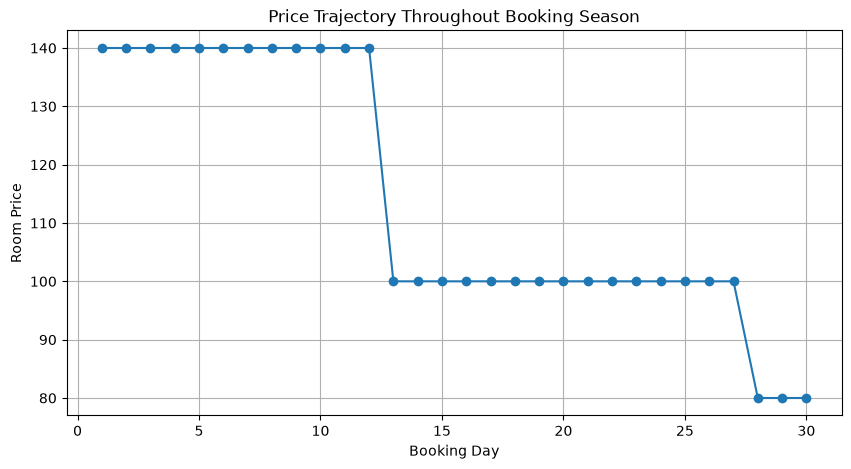

In [7]:
plt.figure(figsize=(10,5))

plt.plot(trajectory["Day"],trajectory["Price"],marker="o")

plt.title("Price Trajectory Throughout Booking Season")

plt.xlabel("Booking Day")

plt.ylabel("Room Price")

plt.grid(True)

plt.show()

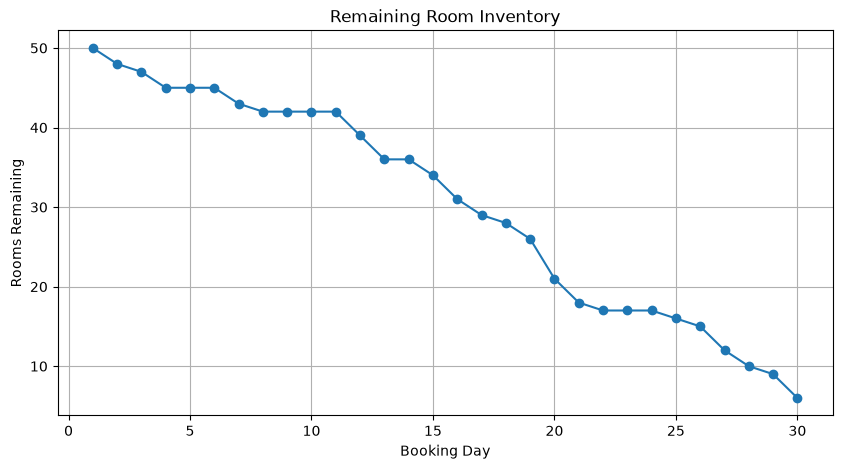

In [8]:
plt.figure(figsize=(10,5))

plt.plot(trajectory["Day"],trajectory["Rooms Remaining"],marker="o")

plt.title("Remaining Room Inventory")

plt.xlabel("Booking Day")

plt.ylabel("Rooms Remaining")

plt.grid(True)

plt.show()

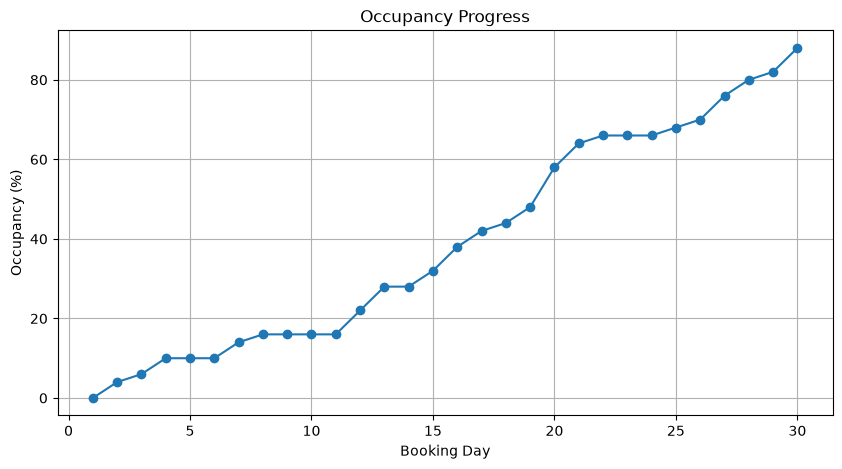

In [9]:
plt.figure(figsize=(10,5))

plt.plot(trajectory["Day"],trajectory["Occupancy (%)"],marker="o")

plt.title("Occupancy Progress")

plt.xlabel("Booking Day")

plt.ylabel("Occupancy (%)")

plt.grid(True)

plt.show()

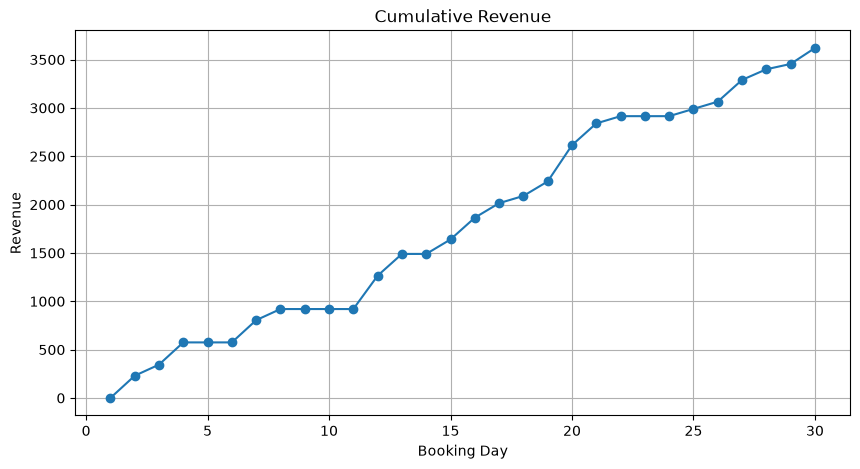

In [10]:
plt.figure(figsize=(10,5))

plt.plot(trajectory["Day"],trajectory["Cumulative Revenue"],marker="o")

plt.title("Cumulative Revenue")

plt.xlabel("Booking Day")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [11]:
print("="*60)
print("Trajectory Analysis")
print("="*60)

print()

print(f"Booking Days : {len(trajectory)}")

print()

print(f"Final Revenue : {trajectory['Cumulative Revenue'].iloc[-1]:.2f}")

print()

print(f"Final Occupancy : {trajectory['Occupancy (%)'].iloc[-1]:.2f}%")

print()

print(f"Average Price : {trajectory['Price'].mean():.2f}")

Trajectory Analysis

Booking Days : 30

Final Revenue : 3620.00

Final Occupancy : 88.00%

Average Price : 114.00
